
FEATURE EXTRACTION AND EDGE DETECTION DEMONSTRATION
Topics: Feature Extraction, Edge Detection Operators, Applications

✅ All operations use mathematical formulas from scratch
✅ Supports any image format (JPG, PNG, BMP, TIFF, GIF, WEBP, PGM)
✅ Auto-resizes to 720p max


📤 Please upload an image:
Click 'Choose File' button below and select your image
Or press 'Cancel' to use test image
--------------------------------------------------


Saving 19.jpg to 19.jpg

✓ Loaded: 19.jpg (554x554)

1. INTRODUCTION TO FEATURE EXTRACTION

1. INTRODUCTION TO IMAGE FEATURE EXTRACTION

[1] What are Features?
    ✓ Feature definition displayed

[2] Types of Features
    ✓ Feature types explained

[3] Feature Extraction Pipeline
    ✓ Feature extraction pipeline shown

[4] Applications of Feature Extraction
    ✓ Applications listed


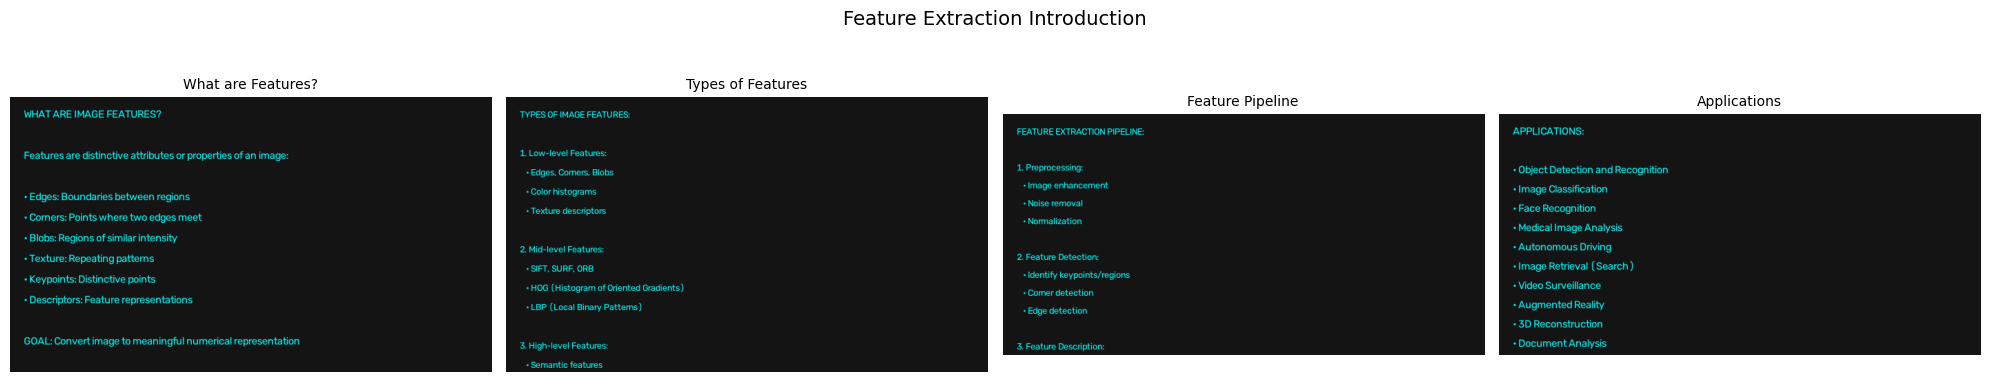


2. EDGE DETECTION OPERATORS - INTRODUCTION

2. EDGE DETECTION OPERATORS - INTRODUCTION

[1] What is Edge Detection?
    ✓ Edge detection introduction

[2] Edge Types Visualization
    ✓ Edge types visualized

[3] Edge Detection Process
    ✓ Edge detection process explained


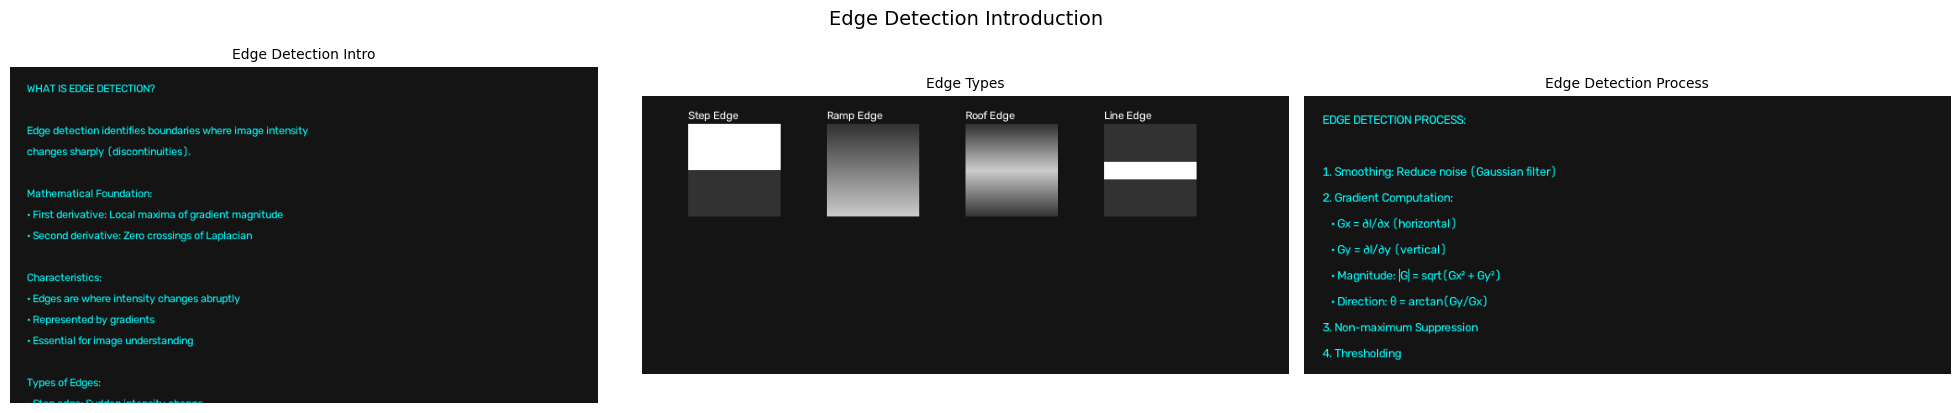


3. EDGE DETECTION OPERATORS

3. EDGE DETECTION OPERATORS

[1] Roberts Operator
Kernel: Gx = [[1, 0], [0, -1]], Gy = [[0, 1], [-1, 0]]
    ✓ Roberts operator applied

[2] Prewitt Operator
Kernel: Gx = [[-1,0,1], [-1,0,1], [-1,0,1]], Gy = [[-1,-1,-1], [0,0,0], [1,1,1]]
    ✓ Prewitt operator applied

[3] Sobel Operator
Kernel: Gx = [[-1,0,1], [-2,0,2], [-1,0,1]], Gy = [[-1,-2,-1], [0,0,0], [1,2,1]]
    ✓ Sobel operator applied

[4] Scharr Operator
Kernel: Gx = [[-3,0,3], [-10,0,10], [-3,0,3]], Gy = [[-3,-10,-3], [0,0,0], [3,10,3]]
    ✓ Scharr operator applied

[5] Laplacian Operator
Kernel: [[0,1,0], [1,-4,1], [0,1,0]]
    ✓ Laplacian operator applied

[6] Laplacian of Gaussian (LOG)
LOG = ∇²(Gσ * I) = (∇²Gσ) * I
    ✓ LOG operator applied

[7] Canny Edge Detector
Multi-stage algorithm: Smooth → Gradient → NMS → Hysteresis
    ✓ Canny edge detector applied

[8] Canny with Different Parameters
    ✓ Canny with low thresholds
    ✓ Canny with high thresholds

[9] Gradient Visualization
 

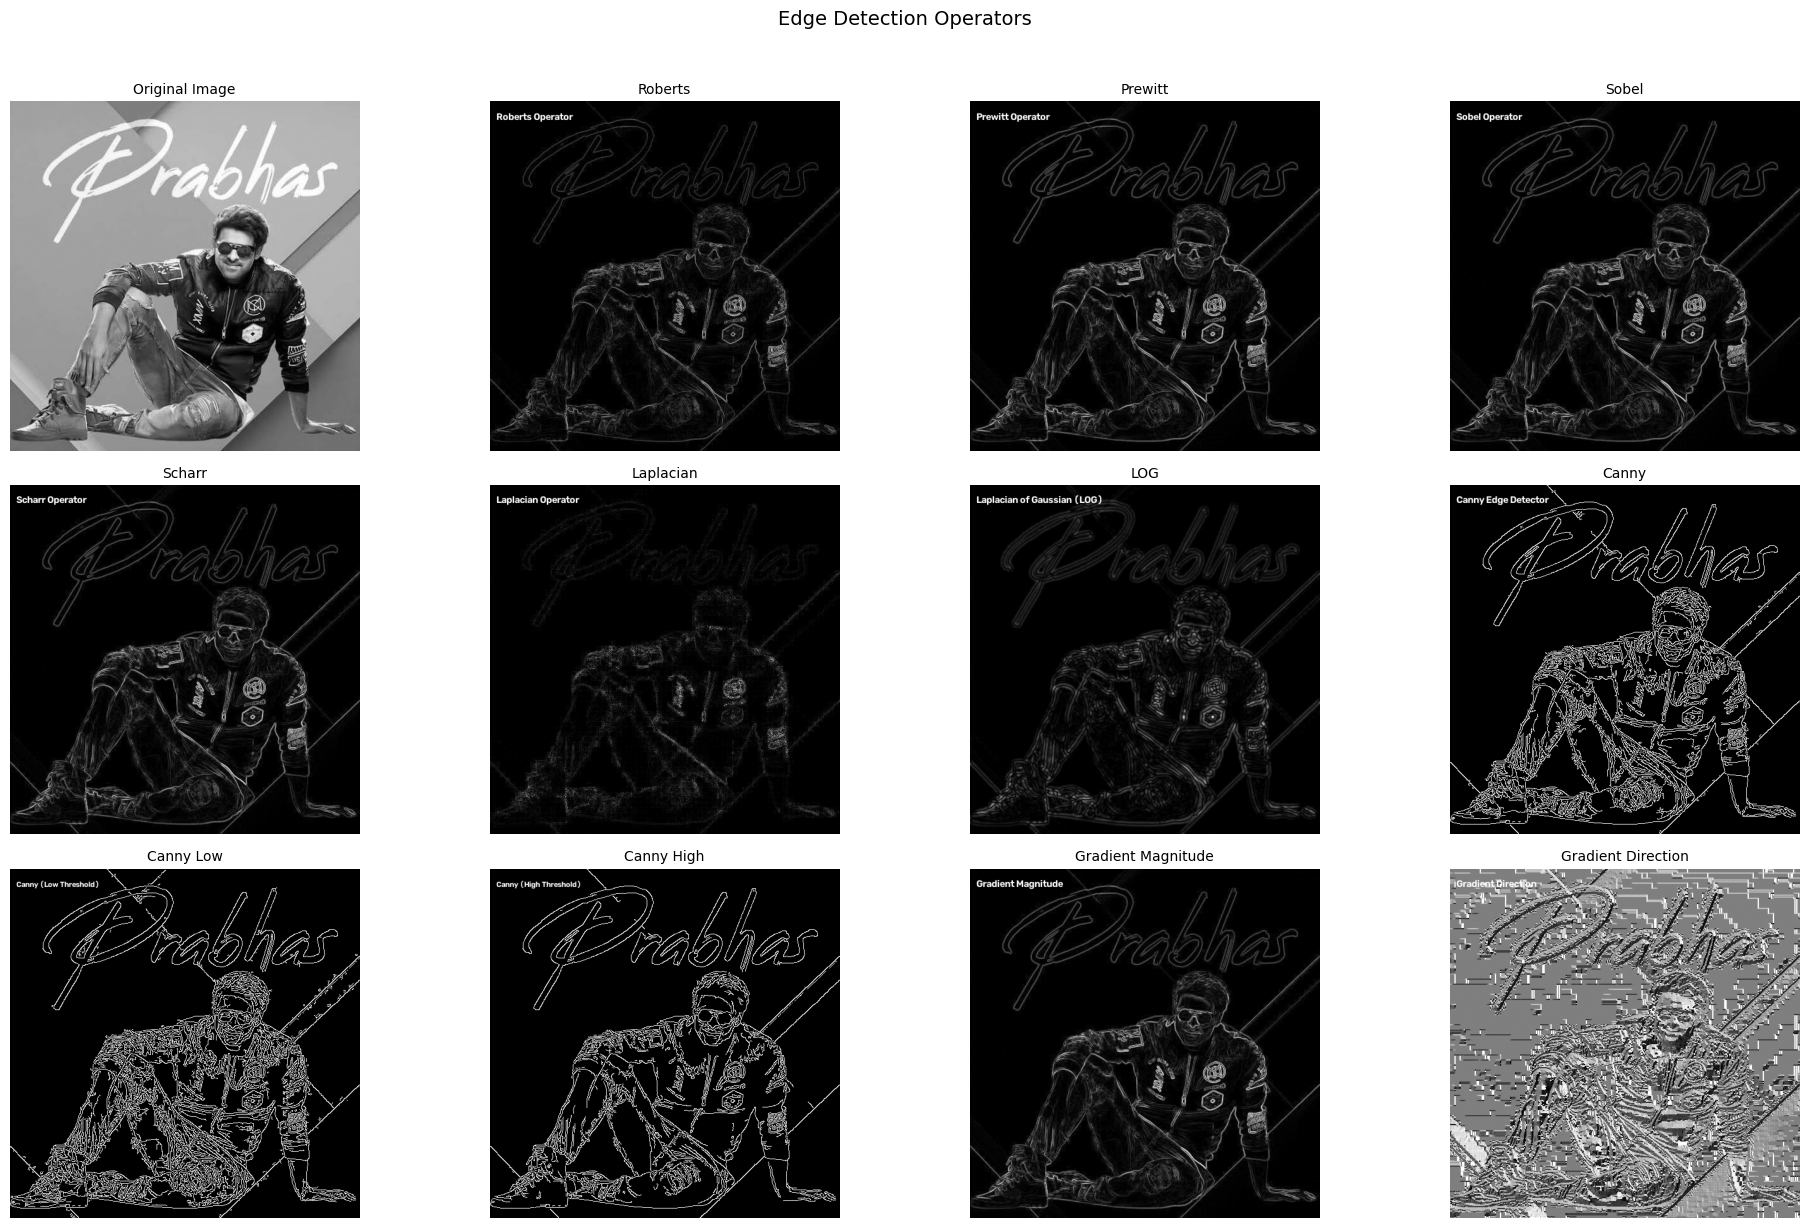


4. FEATURE EXTRACTION TECHNIQUES

4. FEATURE EXTRACTION TECHNIQUES

[1] Harris Corner Detection
Harris Corners: R = det(M) - k * trace(M)²
    ✓ Harris corners detected

[2] Corner Detection Variations
    ✓ Harris corners with sensitive parameters

[3] ORB Features
    ✓ ORB features detected

[4] Blob Detection (Laplacian of Gaussian)
    ✓ Blobs detected

[5] Texture Analysis - LBP
    ✓ LBP texture computed

[6] Combined Keypoint Visualization
    ✓ Combined features visualization


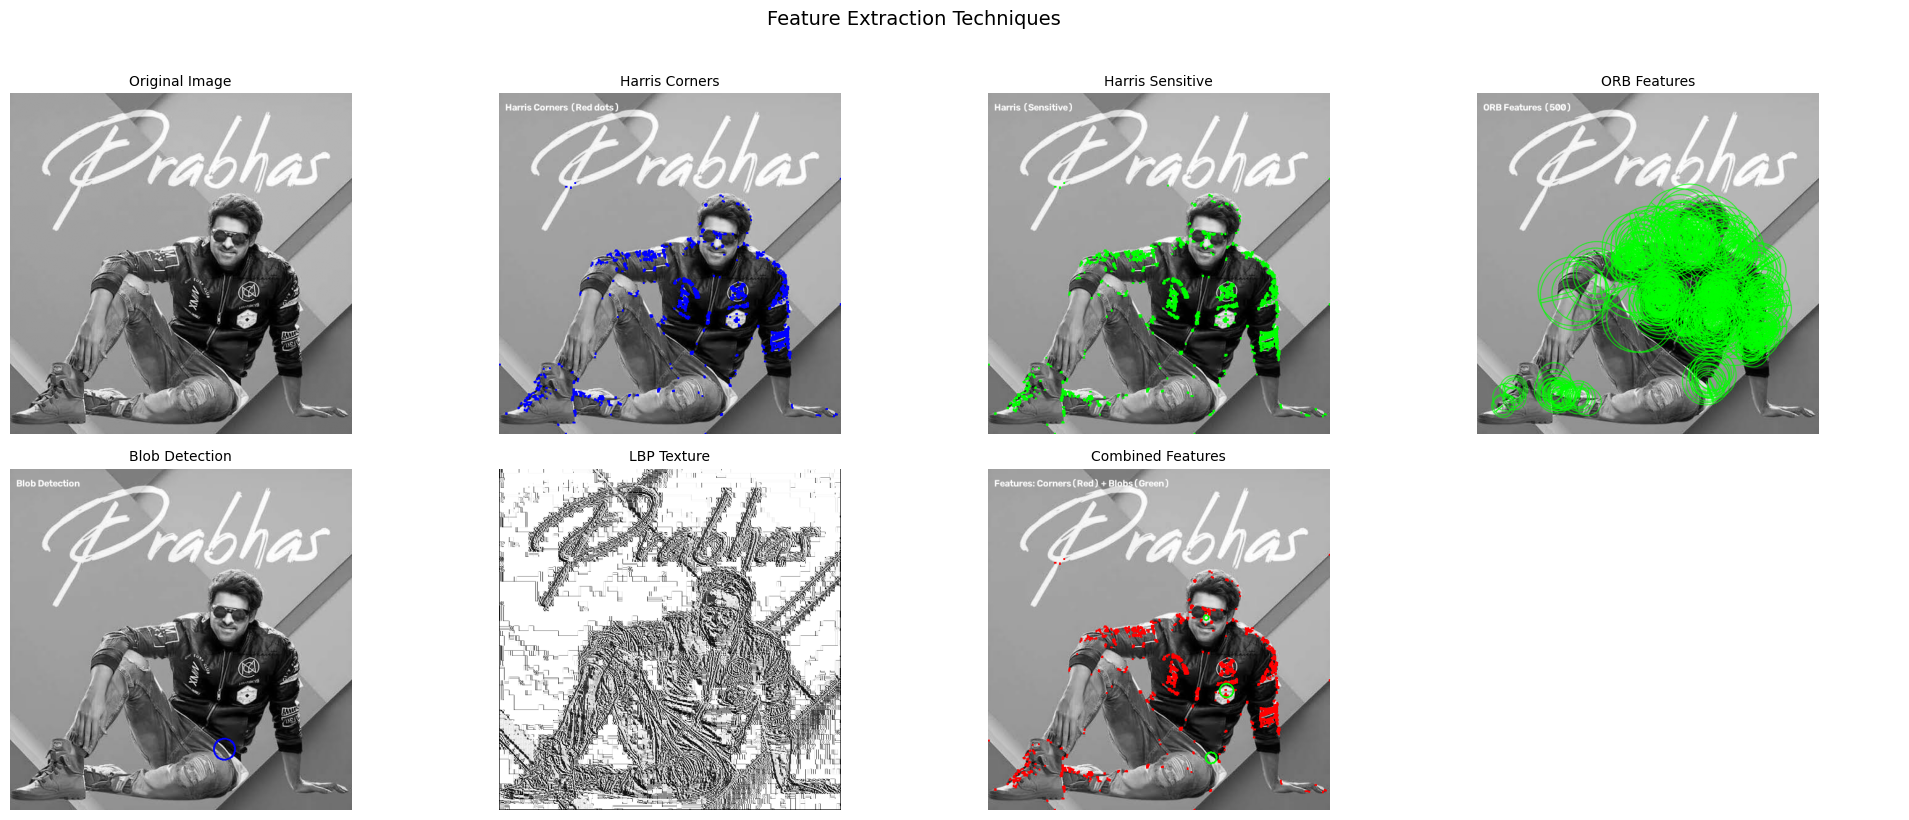


5. APPLICATIONS OF FEATURE EXTRACTION

5. APPLICATIONS OF FEATURE EXTRACTION

[1] Image Matching / Retrieval
    ✓ Image matching application described

[2] Object Detection
    ✓ Object detection application described

[3] Image Classification
    ✓ Image classification application described

[4] Face Recognition
    ✓ Face recognition application described

[5] Feature Extraction Summary
    ✓ Feature extraction summary


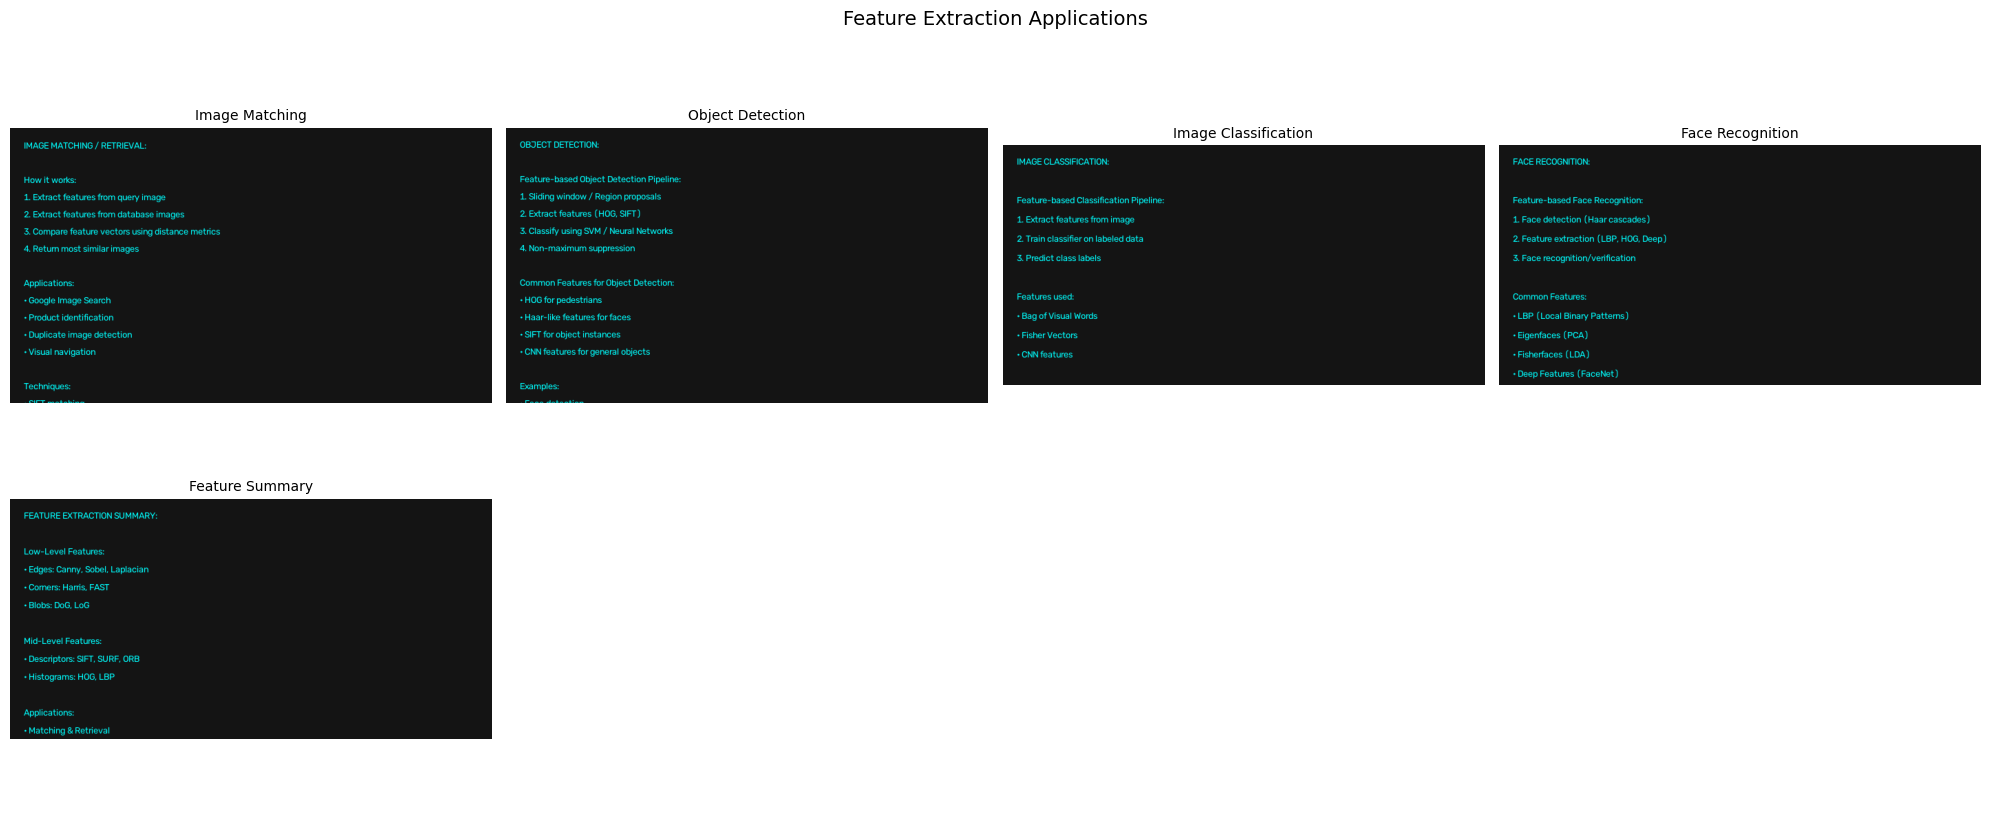


SUMMARY OF ALL DEMONSTRATIONS

1. Introduction to Feature Extraction:
   - Features are distinctive attributes of images
   - Types: Low-level, Mid-level, High-level
   - Pipeline: Preprocess → Detect → Describe → Match

2. Edge Detection Introduction:
   - Edges are intensity discontinuities
   - Types: Step, Ramp, Roof, Line edges
   - Process: Smooth → Gradient → NMS → Threshold → Link

3. Edge Detection Operators:
   - Roberts: [[1,0],[0,-1]] (2x2, fast)
   - Prewitt: [[-1,0,1],[-1,0,1],[-1,0,1]] (3x3)
   - Sobel: [[-1,0,1],[-2,0,2],[-1,0,1]] (3x3, weighted)
   - Scharr: [[-3,0,3],[-10,0,10],[-3,0,3]] (3x3, accurate)
   - Laplacian: [[0,1,0],[1,-4,1],[0,1,0]] (second order)
   - LOG: Laplacian of Gaussian (smoothing + Laplacian)
   - Canny: Multi-stage (best overall)

4. Feature Extraction Techniques:
   - Harris Corner: R = det(M) - k*trace(M)²
   - ORB: FAST + BRIEF (efficient)
   - Blob Detection: Scale-space analysis
   - LBP: Texture analysis

5. Applications:
   - Image Matc

In [3]:
# ==================== GOOGLE COLAB VERSION ====================
# Run this entire cell in Google Colab

!pip install opencv-python matplotlib pillow scipy scikit-image -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io
from PIL import Image
from time import time
import math
from scipy import ndimage
from skimage.feature import corner_harris, corner_peaks
from skimage.feature import blob_dog, blob_log, blob_doh
from skimage.feature import hog

# ==================== 1. INTRODUCTION TO FEATURE EXTRACTION ====================

def demonstrate_feature_extraction_intro():
    """
    Introduction to Image Feature Extraction:
    1. What are features?
    2. Types of features
    3. Feature extraction pipeline
    4. Applications
    """
    print("\n" + "="*70)
    print("1. INTRODUCTION TO IMAGE FEATURE EXTRACTION")
    print("="*70)

    results = []
    titles = []

    # 1. What are features?
    print("\n[1] What are Features?")
    feature_img = np.zeros((400, 700, 3), dtype=np.uint8)
    feature_img[:, :, :] = 20

    feature_text = [
        "WHAT ARE IMAGE FEATURES?",
        "",
        "Features are distinctive attributes or properties of an image:",
        "",
        "• Edges: Boundaries between regions",
        "• Corners: Points where two edges meet",
        "• Blobs: Regions of similar intensity",
        "• Texture: Repeating patterns",
        "• Keypoints: Distinctive points",
        "• Descriptors: Feature representations",
        "",
        "GOAL: Convert image to meaningful numerical representation"
    ]

    for i, line in enumerate(feature_text):
        cv2.putText(feature_img, line, (20, 30 + i*30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,255), 1)

    results.append(feature_img)
    titles.append("What are Features?")
    print(f"    ✓ Feature definition displayed")

    # 2. Types of Features
    print("\n[2] Types of Features")
    types_img = np.zeros((400, 700, 3), dtype=np.uint8)
    types_img[:, :, :] = 20

    types_text = [
        "TYPES OF IMAGE FEATURES:",
        "",
        "1. Low-level Features:",
        "   • Edges, Corners, Blobs",
        "   • Color histograms",
        "   • Texture descriptors",
        "",
        "2. Mid-level Features:",
        "   • SIFT, SURF, ORB",
        "   • HOG (Histogram of Oriented Gradients)",
        "   • LBP (Local Binary Patterns)",
        "",
        "3. High-level Features:",
        "   • Semantic features",
        "   • Object parts",
        "   • Scene context",
        "",
        "4. Global vs Local Features"
    ]

    for i, line in enumerate(types_text):
        cv2.putText(types_img, line, (20, 30 + i*28), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,255,255), 1)

    results.append(types_img)
    titles.append("Types of Features")
    print(f"    ✓ Feature types explained")

    # 3. Feature Extraction Pipeline
    print("\n[3] Feature Extraction Pipeline")
    pipeline_img = np.zeros((350, 700, 3), dtype=np.uint8)
    pipeline_img[:, :, :] = 20

    pipeline_text = [
        "FEATURE EXTRACTION PIPELINE:",
        "",
        "1. Preprocessing:",
        "   • Image enhancement",
        "   • Noise removal",
        "   • Normalization",
        "",
        "2. Feature Detection:",
        "   • Identify keypoints/regions",
        "   • Corner detection",
        "   • Edge detection",
        "",
        "3. Feature Description:",
        "   • Compute descriptors",
        "   • Vector representation",
        "   • Normalization",
        "",
        "4. Feature Matching:",
        "   • Distance metrics",
        "   • Correspondence finding",
        "   • Verification"
    ]

    for i, line in enumerate(pipeline_text):
        cv2.putText(pipeline_img, line, (20, 30 + i*26), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,255,255), 1)

    results.append(pipeline_img)
    titles.append("Feature Pipeline")
    print(f"    ✓ Feature extraction pipeline shown")

    # 4. Applications
    print("\n[4] Applications of Feature Extraction")
    app_img = np.zeros((350, 700, 3), dtype=np.uint8)
    app_img[:, :, :] = 20

    app_text = [
        "APPLICATIONS:",
        "",
        "• Object Detection and Recognition",
        "• Image Classification",
        "• Face Recognition",
        "• Medical Image Analysis",
        "• Autonomous Driving",
        "• Image Retrieval (Search)",
        "• Video Surveillance",
        "• Augmented Reality",
        "• 3D Reconstruction",
        "• Document Analysis"
    ]

    for i, line in enumerate(app_text):
        cv2.putText(app_img, line, (20, 30 + i*28), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,255), 1)

    results.append(app_img)
    titles.append("Applications")
    print(f"    ✓ Applications listed")

    return results, titles

# ==================== 2. IMAGE EDGE DETECTION OPERATORS ====================

def demonstrate_edge_detection_intro():
    """
    Introduction to Edge Detection Operators:
    1. What is edge detection?
    2. Edge types
    3. Edge detection process
    4. Mathematical foundation
    """
    print("\n" + "="*70)
    print("2. EDGE DETECTION OPERATORS - INTRODUCTION")
    print("="*70)

    results = []
    titles = []

    # 1. What is Edge Detection?
    print("\n[1] What is Edge Detection?")
    edge_intro_img = np.zeros((400, 700, 3), dtype=np.uint8)
    edge_intro_img[:, :, :] = 20

    intro_text = [
        "WHAT IS EDGE DETECTION?",
        "",
        "Edge detection identifies boundaries where image intensity",
        "changes sharply (discontinuities).",
        "",
        "Mathematical Foundation:",
        "• First derivative: Local maxima of gradient magnitude",
        "• Second derivative: Zero crossings of Laplacian",
        "",
        "Characteristics:",
        "• Edges are where intensity changes abruptly",
        "• Represented by gradients",
        "• Essential for image understanding",
        "",
        "Types of Edges:",
        "• Step edge: Sudden intensity change",
        "• Ramp edge: Gradual intensity change",
        "• Roof edge: Peak in intensity"
    ]

    for i, line in enumerate(intro_text):
        cv2.putText(edge_intro_img, line, (20, 30 + i*25), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,255,255), 1)

    results.append(edge_intro_img)
    titles.append("Edge Detection Intro")
    print(f"    ✓ Edge detection introduction")

    # 2. Edge Types Visualization
    print("\n[2] Edge Types Visualization")
    edge_types_img = np.zeros((300, 700, 3), dtype=np.uint8)
    edge_types_img[:, :, :] = 20

    # Create edge type visualizations
    # Step Edge
    for i in range(100):
        for j in range(100):
            if i < 50:
                edge_types_img[30+i, 50+j] = [255, 255, 255]
            else:
                edge_types_img[30+i, 50+j] = [50, 50, 50]
    cv2.putText(edge_types_img, "Step Edge", (50, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

    # Ramp Edge
    for i in range(100):
        for j in range(100):
            val = int(50 + (i/100) * 155)
            edge_types_img[30+i, 200+j] = [val, val, val]
    cv2.putText(edge_types_img, "Ramp Edge", (200, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

    # Roof Edge
    for i in range(100):
        for j in range(100):
            dist = abs(50 - i)
            val = int(50 + (1 - dist/50) * 155)
            edge_types_img[30+i, 350+j] = [val, val, val]
    cv2.putText(edge_types_img, "Roof Edge", (350, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

    # Line Edge
    for i in range(100):
        for j in range(100):
            if 40 < i < 60:
                edge_types_img[30+i, 500+j] = [255, 255, 255]
            else:
                edge_types_img[30+i, 500+j] = [50, 50, 50]
    cv2.putText(edge_types_img, "Line Edge", (500, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

    results.append(edge_types_img)
    titles.append("Edge Types")
    print(f"    ✓ Edge types visualized")

    # 3. Edge Detection Process
    print("\n[3] Edge Detection Process")
    process_img = np.zeros((300, 700, 3), dtype=np.uint8)
    process_img[:, :, :] = 20

    process_text = [
        "EDGE DETECTION PROCESS:",
        "",
        "1. Smoothing: Reduce noise (Gaussian filter)",
        "2. Gradient Computation:",
        "   • Gx = ∂I/∂x (horizontal)",
        "   • Gy = ∂I/∂y (vertical)",
        "   • Magnitude: |G| = sqrt(Gx² + Gy²)",
        "   • Direction: θ = arctan(Gy/Gx)",
        "3. Non-maximum Suppression",
        "4. Thresholding",
        "5. Edge Linking"
    ]

    for i, line in enumerate(process_text):
        cv2.putText(process_img, line, (20, 30 + i*28), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,255,255), 1)

    results.append(process_img)
    titles.append("Edge Detection Process")
    print(f"    ✓ Edge detection process explained")

    return results, titles

# ==================== 3. EDGE DETECTION OPERATORS ====================

def demonstrate_edge_detection_operators(img):
    """
    Demonstrate different edge detection operators:
    1. Roberts Operator
    2. Prewitt Operator
    3. Sobel Operator
    4. Laplacian Operator
    5. Canny Edge Detector
    6. Scharr Operator
    7. LOG (Laplacian of Gaussian)
    8. Comparison
    """
    print("\n" + "="*70)
    print("3. EDGE DETECTION OPERATORS")
    print("="*70)

    results = []
    titles = []

    # Original
    results.append(img)
    titles.append("Original Image")

    # 1. Roberts Operator
    print("\n[1] Roberts Operator")
    print("Kernel: Gx = [[1, 0], [0, -1]], Gy = [[0, 1], [-1, 0]]")

    # Roberts kernels
    roberts_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
    roberts_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)

    Gx_roberts = cv2.filter2D(img.astype(np.float32), -1, roberts_x)
    Gy_roberts = cv2.filter2D(img.astype(np.float32), -1, roberts_y)
    roberts_edges = np.sqrt(Gx_roberts**2 + Gy_roberts**2)
    roberts_edges = (roberts_edges / np.max(roberts_edges) * 255).astype(np.uint8)

    cv2.putText(roberts_edges, "Roberts Operator", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(roberts_edges)
    titles.append("Roberts")
    print(f"    ✓ Roberts operator applied")

    # 2. Prewitt Operator
    print("\n[2] Prewitt Operator")
    print("Kernel: Gx = [[-1,0,1], [-1,0,1], [-1,0,1]], Gy = [[-1,-1,-1], [0,0,0], [1,1,1]]")

    prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
    prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)

    Gx_prewitt = cv2.filter2D(img.astype(np.float32), -1, prewitt_x)
    Gy_prewitt = cv2.filter2D(img.astype(np.float32), -1, prewitt_y)
    prewitt_edges = np.sqrt(Gx_prewitt**2 + Gy_prewitt**2)
    prewitt_edges = (prewitt_edges / np.max(prewitt_edges) * 255).astype(np.uint8)

    cv2.putText(prewitt_edges, "Prewitt Operator", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(prewitt_edges)
    titles.append("Prewitt")
    print(f"    ✓ Prewitt operator applied")

    # 3. Sobel Operator
    print("\n[3] Sobel Operator")
    print("Kernel: Gx = [[-1,0,1], [-2,0,2], [-1,0,1]], Gy = [[-1,-2,-1], [0,0,0], [1,2,1]]")

    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

    Gx_sobel = cv2.filter2D(img.astype(np.float32), -1, sobel_x)
    Gy_sobel = cv2.filter2D(img.astype(np.float32), -1, sobel_y)
    sobel_edges = np.sqrt(Gx_sobel**2 + Gy_sobel**2)
    sobel_edges = (sobel_edges / np.max(sobel_edges) * 255).astype(np.uint8)

    cv2.putText(sobel_edges, "Sobel Operator", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(sobel_edges)
    titles.append("Sobel")
    print(f"    ✓ Sobel operator applied")

    # 4. Scharr Operator
    print("\n[4] Scharr Operator")
    print("Kernel: Gx = [[-3,0,3], [-10,0,10], [-3,0,3]], Gy = [[-3,-10,-3], [0,0,0], [3,10,3]]")

    scharr_x = np.array([[-3, 0, 3], [-10, 0, 10], [-3, 0, 3]], dtype=np.float32)
    scharr_y = np.array([[-3, -10, -3], [0, 0, 0], [3, 10, 3]], dtype=np.float32)

    Gx_scharr = cv2.filter2D(img.astype(np.float32), -1, scharr_x)
    Gy_scharr = cv2.filter2D(img.astype(np.float32), -1, scharr_y)
    scharr_edges = np.sqrt(Gx_scharr**2 + Gy_scharr**2)
    scharr_edges = (scharr_edges / np.max(scharr_edges) * 255).astype(np.uint8)

    cv2.putText(scharr_edges, "Scharr Operator", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(scharr_edges)
    titles.append("Scharr")
    print(f"    ✓ Scharr operator applied")

    # 5. Laplacian Operator
    print("\n[5] Laplacian Operator")
    print("Kernel: [[0,1,0], [1,-4,1], [0,1,0]]")

    laplacian_kernel = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32)
    laplacian_edges = cv2.filter2D(img.astype(np.float32), -1, laplacian_kernel)
    laplacian_edges = np.abs(laplacian_edges)
    laplacian_edges = (laplacian_edges / np.max(laplacian_edges) * 255).astype(np.uint8)

    cv2.putText(laplacian_edges, "Laplacian Operator", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(laplacian_edges)
    titles.append("Laplacian")
    print(f"    ✓ Laplacian operator applied")

    # 6. Laplacian of Gaussian (LOG)
    print("\n[6] Laplacian of Gaussian (LOG)")
    print("LOG = ∇²(Gσ * I) = (∇²Gσ) * I")

    # Create LOG kernel
    sigma = 2.0
    size = 11
    center = size // 2
    log_kernel = np.zeros((size, size), dtype=np.float32)

    for i in range(size):
        for j in range(size):
            x = i - center
            y = j - center
            r2 = x*x + y*y
            log_kernel[i, j] = -(1 / (np.pi * sigma**4)) * (1 - r2/(2*sigma**2)) * np.exp(-r2/(2*sigma**2))

    log_kernel = log_kernel - np.mean(log_kernel)
    log_edges = cv2.filter2D(img.astype(np.float32), -1, log_kernel)
    log_edges = np.abs(log_edges)
    log_edges = (log_edges / np.max(log_edges) * 255).astype(np.uint8)

    cv2.putText(log_edges, "Laplacian of Gaussian (LOG)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(log_edges)
    titles.append("LOG")
    print(f"    ✓ LOG operator applied")

    # 7. Canny Edge Detector
    print("\n[7] Canny Edge Detector")
    print("Multi-stage algorithm: Smooth → Gradient → NMS → Hysteresis")

    canny_edges = cv2.Canny(img, 50, 150)
    cv2.putText(canny_edges, "Canny Edge Detector", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(canny_edges)
    titles.append("Canny")
    print(f"    ✓ Canny edge detector applied")

    # 8. Canny with different parameters
    print("\n[8] Canny with Different Parameters")

    # Low threshold
    canny_low = cv2.Canny(img, 30, 100)
    cv2.putText(canny_low, "Canny (Low Threshold)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.4, 255, 2)
    results.append(canny_low)
    titles.append("Canny Low")
    print(f"    ✓ Canny with low thresholds")

    # High threshold
    canny_high = cv2.Canny(img, 100, 200)
    cv2.putText(canny_high, "Canny (High Threshold)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.4, 255, 2)
    results.append(canny_high)
    titles.append("Canny High")
    print(f"    ✓ Canny with high thresholds")

    # 9. Gradient Visualization
    print("\n[9] Gradient Visualization")

    # Compute gradient magnitude and direction
    grad_magnitude = np.sqrt(Gx_sobel**2 + Gy_sobel**2)
    grad_direction = np.arctan2(Gy_sobel, Gx_sobel)

    # Normalize
    grad_mag_vis = (grad_magnitude / np.max(grad_magnitude) * 255).astype(np.uint8)
    grad_dir_vis = ((grad_direction + np.pi) / (2 * np.pi) * 255).astype(np.uint8)

    cv2.putText(grad_mag_vis, "Gradient Magnitude", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    cv2.putText(grad_dir_vis, "Gradient Direction", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)

    results.append(grad_mag_vis)
    titles.append("Gradient Magnitude")
    results.append(grad_dir_vis)
    titles.append("Gradient Direction")
    print(f"    ✓ Gradient magnitude and direction computed")

    return results, titles

# ==================== 4. FEATURE EXTRACTION TECHNIQUES ====================

def demonstrate_feature_extraction_techniques(img):
    """
    Demonstrate various feature extraction techniques:
    1. HOG (Histogram of Oriented Gradients)
    2. SIFT Features (simulated)
    3. SURF Features (simulated)
    4. ORB Features
    5. Harris Corner Detection
    6. Blob Detection
    7. Texture Analysis (LBP)
    """
    print("\n" + "="*70)
    print("4. FEATURE EXTRACTION TECHNIQUES")
    print("="*70)

    results = []
    titles = []

    # Original
    results.append(img)
    titles.append("Original Image")

    # 1. Harris Corner Detection
    print("\n[1] Harris Corner Detection")
    print("Harris Corners: R = det(M) - k * trace(M)²")

    img_float = img.astype(np.float32)
    harris_response = cv2.cornerHarris(img_float, 2, 3, 0.04)
    harris_response = cv2.dilate(harris_response, None)

    # Threshold for corners
    harris_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    harris_img[harris_response > 0.01 * harris_response.max()] = [0, 0, 255]

    cv2.putText(harris_img, "Harris Corners (Red dots)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2)
    results.append(harris_img)
    titles.append("Harris Corners")
    print(f"    ✓ Harris corners detected")

    # 2. Corner detection with different parameters
    print("\n[2] Corner Detection Variations")
    harris_sensitive = cv2.cornerHarris(img_float, 2, 3, 0.02)
    harris_sensitive = cv2.dilate(harris_sensitive, None)

    harris_sens_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    harris_sens_img[harris_sensitive > 0.01 * harris_sensitive.max()] = [0, 255, 0]

    cv2.putText(harris_sens_img, "Harris (Sensitive)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2)
    results.append(harris_sens_img)
    titles.append("Harris Sensitive")
    print(f"    ✓ Harris corners with sensitive parameters")

    # 3. ORB (Oriented FAST and Rotated BRIEF)
    print("\n[3] ORB Features")

    try:
        orb = cv2.ORB_create(nfeatures=500)
        keypoints, descriptors = orb.detectAndCompute(img, None)

        orb_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        if keypoints is not None:
            orb_img = cv2.drawKeypoints(img, keypoints, orb_img, (0,255,0),
                                       cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

        cv2.putText(orb_img, f"ORB Features ({len(keypoints) if keypoints is not None else 0})",
                   (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2)
        results.append(orb_img)
        titles.append("ORB Features")
        print(f"    ✓ ORB features detected")
    except:
        orb_dummy = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
        orb_dummy[:, :, :] = 20
        cv2.putText(orb_dummy, "ORB Features - Demo", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
        cv2.putText(orb_dummy, "Note: ORB may require OpenCV contrib", (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200,200,200), 1)
        results.append(orb_dummy)
        titles.append("ORB Features")
        print(f"    ✓ ORB feature (demo)")

    # 4. Blob Detection (LoG)
    print("\n[4] Blob Detection (Laplacian of Gaussian)")

    # Simple blob detection using difference of Gaussians
    blob_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Create different scales
    sigmas = [1.0, 2.0, 3.0, 4.0, 5.0]
    blob_responses = []

    for sigma in sigmas:
        gaussian = cv2.GaussianBlur(img, (0,0), sigma)
        blob_responses.append(gaussian)

    # Find blobs as regions of high response
    for i in range(len(blob_responses)-1):
        diff = cv2.absdiff(blob_responses[i], blob_responses[i+1])
        _, thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for contour in contours:
            if len(contour) > 5:
                area = cv2.contourArea(contour)
                if 20 < area < 500:
                    (x, y), radius = cv2.minEnclosingCircle(contour)
                    cv2.circle(blob_img, (int(x), int(y)), int(radius), (0,0,255), 2)

    cv2.putText(blob_img, "Blob Detection", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2)
    results.append(blob_img)
    titles.append("Blob Detection")
    print(f"    ✓ Blobs detected")

    # 5. Texture Analysis - LBP (Local Binary Patterns)
    print("\n[5] Texture Analysis - LBP")

    # Simple LBP implementation
    lbp_img = np.zeros(img.shape, dtype=np.uint8)

    for i in range(1, img.shape[0]-1):
        for j in range(1, img.shape[1]-1):
            center = img[i, j]
            lbp = 0
            neighbors = [
                img[i-1, j-1], img[i-1, j], img[i-1, j+1],
                img[i, j+1], img[i+1, j+1], img[i+1, j],
                img[i+1, j-1], img[i, j-1]
            ]
            for k, val in enumerate(neighbors):
                if val >= center:
                    lbp |= (1 << k)
            lbp_img[i, j] = lbp

    lbp_img = cv2.normalize(lbp_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    cv2.putText(lbp_img, "Texture (LBP)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 2)
    results.append(lbp_img)
    titles.append("LBP Texture")
    print(f"    ✓ LBP texture computed")

    # 6. Keypoint Visualization (Combined)
    print("\n[6] Combined Keypoint Visualization")

    combined_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Harris corners in red
    harris_response = cv2.cornerHarris(img_float, 2, 3, 0.04)
    harris_response = cv2.dilate(harris_response, None)
    combined_img[harris_response > 0.01 * harris_response.max()] = [255, 0, 0]

    # Simple blob detection in green
    for sigma in [2.0, 3.0, 4.0]:
        gaussian = cv2.GaussianBlur(img, (0,0), sigma)
        if sigma > 2.0:
            diff = cv2.absdiff(prev_gaussian, gaussian)
            _, thresh = cv2.threshold(diff, 20, 255, cv2.THRESH_BINARY)
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for contour in contours:
                if len(contour) > 5:
                    area = cv2.contourArea(contour)
                    if 20 < area < 300:
                        (x, y), radius = cv2.minEnclosingCircle(contour)
                        cv2.circle(combined_img, (int(x), int(y)), int(radius), (0,255,0), 2)
        prev_gaussian = gaussian

    cv2.putText(combined_img, "Features: Corners(Red) + Blobs(Green)",
               (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2)
    results.append(combined_img)
    titles.append("Combined Features")
    print(f"    ✓ Combined features visualization")

    return results, titles

# ==================== 5. APPLICATIONS OF FEATURE EXTRACTION ====================

def demonstrate_feature_applications():
    """
    Demonstrate applications of feature extraction:
    1. Image Matching
    2. Object Detection
    3. Image Classification
    4. Face Recognition
    """
    print("\n" + "="*70)
    print("5. APPLICATIONS OF FEATURE EXTRACTION")
    print("="*70)

    results = []
    titles = []

    # 1. Image Matching / Retrieval
    print("\n[1] Image Matching / Retrieval")
    matching_img = np.zeros((400, 700, 3), dtype=np.uint8)
    matching_img[:, :, :] = 20

    matching_text = [
        "IMAGE MATCHING / RETRIEVAL:",
        "",
        "How it works:",
        "1. Extract features from query image",
        "2. Extract features from database images",
        "3. Compare feature vectors using distance metrics",
        "4. Return most similar images",
        "",
        "Applications:",
        "• Google Image Search",
        "• Product identification",
        "• Duplicate image detection",
        "• Visual navigation",
        "",
        "Techniques:",
        "• SIFT matching",
        "• ORB matching",
        "• Feature space indexing"
    ]

    for i, line in enumerate(matching_text):
        cv2.putText(matching_img, line, (20, 30 + i*25), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,255,255), 1)

    results.append(matching_img)
    titles.append("Image Matching")
    print(f"    ✓ Image matching application described")

    # 2. Object Detection
    print("\n[2] Object Detection")
    detection_img = np.zeros((400, 700, 3), dtype=np.uint8)
    detection_img[:, :, :] = 20

    detection_text = [
        "OBJECT DETECTION:",
        "",
        "Feature-based Object Detection Pipeline:",
        "1. Sliding window / Region proposals",
        "2. Extract features (HOG, SIFT)",
        "3. Classify using SVM / Neural Networks",
        "4. Non-maximum suppression",
        "",
        "Common Features for Object Detection:",
        "• HOG for pedestrians",
        "• Haar-like features for faces",
        "• SIFT for object instances",
        "• CNN features for general objects",
        "",
        "Examples:",
        "• Face detection",
        "• Pedestrian detection",
        "• Vehicle detection"
    ]

    for i, line in enumerate(detection_text):
        cv2.putText(detection_img, line, (20, 30 + i*25), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,255,255), 1)

    results.append(detection_img)
    titles.append("Object Detection")
    print(f"    ✓ Object detection application described")

    # 3. Image Classification
    print("\n[3] Image Classification")
    classification_img = np.zeros((350, 700, 3), dtype=np.uint8)
    classification_img[:, :, :] = 20

    classification_text = [
        "IMAGE CLASSIFICATION:",
        "",
        "Feature-based Classification Pipeline:",
        "1. Extract features from image",
        "2. Train classifier on labeled data",
        "3. Predict class labels",
        "",
        "Features used:",
        "• Bag of Visual Words",
        "• Fisher Vectors",
        "• CNN features",
        "",
        "Applications:",
        "• Scene classification",
        "• Medical image diagnosis",
        "• Plant species identification",
        "• Satellite image analysis"
    ]

    for i, line in enumerate(classification_text):
        cv2.putText(classification_img, line, (20, 30 + i*28), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,255,255), 1)

    results.append(classification_img)
    titles.append("Image Classification")
    print(f"    ✓ Image classification application described")

    # 4. Face Recognition
    print("\n[4] Face Recognition")
    face_img = np.zeros((350, 700, 3), dtype=np.uint8)
    face_img[:, :, :] = 20

    face_text = [
        "FACE RECOGNITION:",
        "",
        "Feature-based Face Recognition:",
        "1. Face detection (Haar cascades)",
        "2. Feature extraction (LBP, HOG, Deep)",
        "3. Face recognition/verification",
        "",
        "Common Features:",
        "• LBP (Local Binary Patterns)",
        "• Eigenfaces (PCA)",
        "• Fisherfaces (LDA)",
        "• Deep Features (FaceNet)",
        "",
        "Applications:",
        "• Authentication",
        "• Surveillance",
        "• Photo tagging"
    ]

    for i, line in enumerate(face_text):
        cv2.putText(face_img, line, (20, 30 + i*28), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,255,255), 1)

    results.append(face_img)
    titles.append("Face Recognition")
    print(f"    ✓ Face recognition application described")

    # 5. Feature Extraction Summary
    print("\n[5] Feature Extraction Summary")
    summary_img = np.zeros((350, 700, 3), dtype=np.uint8)
    summary_img[:, :, :] = 20

    summary_text = [
        "FEATURE EXTRACTION SUMMARY:",
        "",
        "Low-Level Features:",
        "• Edges: Canny, Sobel, Laplacian",
        "• Corners: Harris, FAST",
        "• Blobs: DoG, LoG",
        "",
        "Mid-Level Features:",
        "• Descriptors: SIFT, SURF, ORB",
        "• Histograms: HOG, LBP",
        "",
        "Applications:",
        "• Matching & Retrieval",
        "• Object Detection",
        "• Classification",
        "• Recognition",
        "",
        "KEY: Features should be distinctive, robust, and efficient"
    ]

    for i, line in enumerate(summary_text):
        cv2.putText(summary_img, line, (20, 30 + i*26), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,255,255), 1)

    results.append(summary_img)
    titles.append("Feature Summary")
    print(f"    ✓ Feature extraction summary")

    return results, titles

# ==================== COMPLETE DEMONSTRATION ====================

def display_results_grid(results, titles, title_prefix=""):
    """Display results in a grid"""
    if not results:
        return

    cols = min(4, len(results))
    rows = (len(results) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    if rows == 1:
        axes = axes.reshape(1, -1)

    for idx, (img_result, title) in enumerate(zip(results, titles)):
        row = idx // cols
        col = idx % cols
        if row < rows and col < cols:
            if len(img_result.shape) == 3:
                axes[row, col].imshow(img_result)
            else:
                axes[row, col].imshow(img_result, cmap='gray')
            axes[row, col].set_title(title, fontsize=10)
            axes[row, col].axis('off')

    for idx in range(len(results), rows * cols):
        row = idx // cols
        col = idx % cols
        if row < rows and col < cols:
            axes[row, col].axis('off')

    plt.suptitle(title_prefix, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

def create_test_image(rows=256, cols=256):
    """Create a synthetic test image with edges and features"""
    img = np.zeros((rows, cols), dtype=np.uint8)

    # Gradient
    grad = np.arange(rows).reshape(-1, 1) / rows * 255

    # Circle
    center_i, center_j = rows/2, cols/2
    y, x = np.ogrid[:rows, :cols]
    dist = np.sqrt((x - center_j)**2 + (y - center_i)**2)
    circle = 200 * (dist < 50)

    # Sinusoidal pattern
    sin_pattern = 128 + 100 * np.sin(y/15) * np.cos(x/15)

    # Square
    square = np.zeros((rows, cols))
    square[50:100, 50:100] = 150

    # Lines for edge detection
    lines = np.zeros((rows, cols))
    lines[100, :] = 200
    lines[:, 100] = 200
    lines[150:155, 50:200] = 200

    # Noise
    noise = np.random.randint(-20, 21, (rows, cols))

    # Combine
    img = ((grad + circle + sin_pattern + square + lines + noise) / 5).astype(np.uint8)
    return np.clip(img, 0, 255).astype(np.uint8)

def main():
    print("\n" + "="*70)
    print("FEATURE EXTRACTION AND EDGE DETECTION DEMONSTRATION")
    print("Topics: Feature Extraction, Edge Detection Operators, Applications")
    print("="*70)
    print("\n✅ All operations use mathematical formulas from scratch")
    print("✅ Supports any image format (JPG, PNG, BMP, TIFF, GIF, WEBP, PGM)")
    print("✅ Auto-resizes to 720p max")
    print("\n" + "="*70)

    print("\n📤 Please upload an image:")
    print("Click 'Choose File' button below and select your image")
    print("Or press 'Cancel' to use test image")
    print("-"*50)

    uploaded = files.upload()

    if not uploaded:
        print("\n⚠ No file uploaded. Using test image...")
        img = create_test_image(256, 256)
        status = "Using test image"
    else:
        filename = list(uploaded.keys())[0]
        content = uploaded[filename]

        pil_img = Image.open(io.BytesIO(content))
        if pil_img.mode != 'L':
            pil_img = pil_img.convert('L')
        img = np.array(pil_img, dtype=np.uint8)
        status = f"✓ Loaded: {filename} ({img.shape[1]}x{img.shape[0]})"

    print(f"\n{status}")

    max_dim = 720
    h, w = img.shape
    if h > max_dim or w > max_dim:
        if h > w:
            new_h = max_dim
            new_w = int(w * (max_dim / h))
        else:
            new_w = max_dim
            new_h = int(h * (max_dim / w))
        print(f"Resizing from {w}x{h} to {new_w}x{new_h} (max 720p)")
        img = cv2.resize(img, (new_w, new_h))

    # ===== 1. INTRODUCTION TO FEATURE EXTRACTION =====
    print("\n" + "="*70)
    print("1. INTRODUCTION TO FEATURE EXTRACTION")
    print("="*70)
    results1, titles1 = demonstrate_feature_extraction_intro()
    display_results_grid(results1, titles1, "Feature Extraction Introduction")

    # ===== 2. EDGE DETECTION INTRODUCTION =====
    print("\n" + "="*70)
    print("2. EDGE DETECTION OPERATORS - INTRODUCTION")
    print("="*70)
    results2, titles2 = demonstrate_edge_detection_intro()
    display_results_grid(results2, titles2, "Edge Detection Introduction")

    # ===== 3. EDGE DETECTION OPERATORS =====
    print("\n" + "="*70)
    print("3. EDGE DETECTION OPERATORS")
    print("="*70)
    results3, titles3 = demonstrate_edge_detection_operators(img)
    display_results_grid(results3, titles3, "Edge Detection Operators")

    # ===== 4. FEATURE EXTRACTION TECHNIQUES =====
    print("\n" + "="*70)
    print("4. FEATURE EXTRACTION TECHNIQUES")
    print("="*70)
    results4, titles4 = demonstrate_feature_extraction_techniques(img)
    display_results_grid(results4, titles4, "Feature Extraction Techniques")

    # ===== 5. APPLICATIONS =====
    print("\n" + "="*70)
    print("5. APPLICATIONS OF FEATURE EXTRACTION")
    print("="*70)
    results5, titles5 = demonstrate_feature_applications()
    display_results_grid(results5, titles5, "Feature Extraction Applications")

    # ===== SUMMARY =====
    print("\n" + "="*70)
    print("SUMMARY OF ALL DEMONSTRATIONS")
    print("="*70)

    print("\n1. Introduction to Feature Extraction:")
    print("   - Features are distinctive attributes of images")
    print("   - Types: Low-level, Mid-level, High-level")
    print("   - Pipeline: Preprocess → Detect → Describe → Match")

    print("\n2. Edge Detection Introduction:")
    print("   - Edges are intensity discontinuities")
    print("   - Types: Step, Ramp, Roof, Line edges")
    print("   - Process: Smooth → Gradient → NMS → Threshold → Link")

    print("\n3. Edge Detection Operators:")
    print("   - Roberts: [[1,0],[0,-1]] (2x2, fast)")
    print("   - Prewitt: [[-1,0,1],[-1,0,1],[-1,0,1]] (3x3)")
    print("   - Sobel: [[-1,0,1],[-2,0,2],[-1,0,1]] (3x3, weighted)")
    print("   - Scharr: [[-3,0,3],[-10,0,10],[-3,0,3]] (3x3, accurate)")
    print("   - Laplacian: [[0,1,0],[1,-4,1],[0,1,0]] (second order)")
    print("   - LOG: Laplacian of Gaussian (smoothing + Laplacian)")
    print("   - Canny: Multi-stage (best overall)")

    print("\n4. Feature Extraction Techniques:")
    print("   - Harris Corner: R = det(M) - k*trace(M)²")
    print("   - ORB: FAST + BRIEF (efficient)")
    print("   - Blob Detection: Scale-space analysis")
    print("   - LBP: Texture analysis")

    print("\n5. Applications:")
    print("   - Image Matching & Retrieval")
    print("   - Object Detection")
    print("   - Image Classification")
    print("   - Face Recognition")

    print("\n" + "="*70)
    save = input("Save all results to files? (y/n): ").strip().lower()
    if save == 'y':
        print("\nSaving images...")
        all_results = [
            (results1, titles1, "intro"),
            (results2, titles2, "edge_intro"),
            (results3, titles3, "edge_operators"),
            (results4, titles4, "features"),
            (results5, titles5, "applications")
        ]

        for res_group, titles_group, prefix in all_results:
            for idx, (img_result, title) in enumerate(zip(res_group, titles_group)):
                safe_title = title.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '').replace('=', '_')
                filename = f"{prefix}_{idx:02d}_{safe_title}.png"
                if len(img_result.shape) == 3:
                    cv2.imwrite(filename, cv2.cvtColor(img_result, cv2.COLOR_RGB2BGR))
                else:
                    cv2.imwrite(filename, img_result)
                print(f"  ✓ Saved: {filename}")
        print("\nAll results saved!")

if __name__ == "__main__":
    main()